0.7318435754189944
Survived    0.0
Pclass      0.0
Sex         0.0
Age         0.0
Fare        0.0
family      0.0
dtype: float64


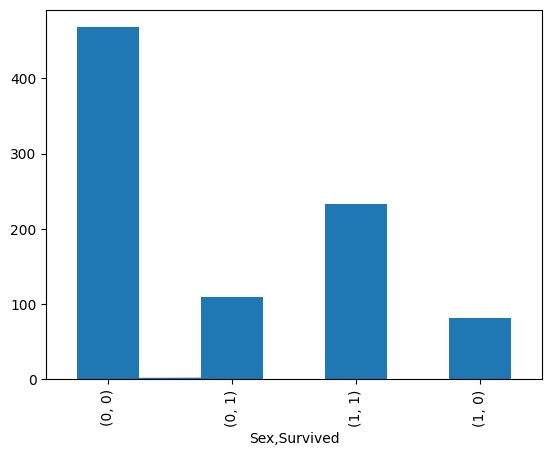

In [274]:
import pandas as pd

# Load Titanic dataset from URL
ship = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv")

# Fill missing Age values with mean (basic data cleaning)
ship['Age'] = ship['Age'].fillna(ship['Age'].mean())

# Convert Sex into numbers (ML models need numbers, not text)
ship['Sex'] = ship['Sex'].map({"male": 0, "female": 1})

# Create new feature: total family size
ship['family'] = ship['Parch'] + ship['SibSp']

# Drop columns that are not useful for prediction
ship.drop(['PassengerId','Name','Ticket','Cabin','Embarked','Parch','SibSp'],
          axis=1, inplace=True)

# Target variable (what we want to predict)
y = ship['Survived'].values

# Features (everything except Survived)
X = ship.drop('Survived', axis=1).values

from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
model = DecisionTreeClassifier()

# Train model on training data
model.fit(X_train, y_train)

# Get probabilities (chance of survival = 1)
positive_probabilities = model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_curve

# Compute ROC curve (model performance at different thresholds)
fpr, tpr, thresholds = roc_curve(y_test, positive_probabilities)

import matplotlib.pyplot as plt

# Plot ROC curve (better curve = better model)
plt.plot(fpr, tpr)

# Model accuracy on test data
print(model.score(X_test, y_test))

# Survival analysis by gender (EDA - data insight)
ship.groupby('Sex')['Survived'].value_counts().plot(kind='bar')

# Percentage of missing values in each column
print((ship.isnull().sum() / ship.shape[0]) * 100)